## Lab 2: Visualizing Text

* Dataset: books.txt (Harry Potter series)
* Tasks (use the first 3 books; for each book):
  * Check whether all chapters in the book are of comparable length.
  * If they differ, identify which chapter is the shortest and which is the longest.
  * Count how often each of these main characters appears. As shown in the class, we’ll focus on these characters:
    * Harry Potter (Harry)
    * Ron Weasley (Ron)
    * Hermione Granger (Hermione)
    * Dobby
    * Draco Malfoy (Malfoy)
    * Lord Voldemort (Voldemort, You know who)
    * Professor Severus Snape (Snape)
    * Professor Albus Dumbledore (Dumbledore)
    * Rubeus Hagrid (Hagrid)
    * Sirius Black (Sirius)
  * Pick two proper visualizations to display character frequencies. Also provide a reason for choosing them.
  * Find out if Harry dominates every chapter, or are there shifts?

In [1]:
import re
import nltk
from nltk.tokenize import word_tokenize

In [2]:
from text_analytics.utils import extract_books
# 1. Load books directly (defaults to data/books.txt)
books = extract_books()

# 2. Access a specific book
target_book = "Harry Potter and the Sorcerer’s Stone"
sorcerer_stone = books[target_book]

print(f"Book title: {target_book}")
print(f"Total lines: {len(sorcerer_stone['content'])}")

Book title: Harry Potter and the Sorcerer’s Stone
Total lines: 3132


In [3]:
def get_chapters(book):
    chapters = []
    chapter_content = None
    for line in book['content']:
        if re.match(r'Chapter \d+', line):
            if chapter_content:
                chapters.append("\n".join(chapter_content))
            chapter_content = []
        else:
            if chapter_content is not None:
                chapter_content.append(line.lower())

    if chapter_content:
        chapters.append("\n".join(chapter_content))

    return chapters

In [4]:
sorcerer_chapters = get_chapters(sorcerer_stone)
sorcerer_chapters[0]

'the boy who lived\nmr. and mrs. dursley, of number four, privet drive, were proud to say that they were perfectly normal, thank you very much. they were the last people you’d expect to be in\xadvolved in anything strange or mysterious, because they just didn’t hold with such nonsense.\nmr. dursley was the director of a firm called grunnings, which made drills. he was a big, beefy man with hardly any neck, al\xadthough he did have a very large mustache. mrs. dursley was thin and blonde and had nearly twice the usual amount of neck, which came in very useful as she spent so much of her time craning over garden fences, spying on the neighbors. the dursleys had a small son called dudley and in their opinion there was no finer boy any\xadwhere.\nthe dursleys had everything they wanted, but they also had a secret, and their greatest fear was that somebody would discover it. they didn’t think they could bear it if anyone found out about the potters. mrs. potter was mrs. dursley’s sister, but

In [5]:
books.keys()

dict_keys(['Harry Potter and the Chamber of Secrets', 'Harry Potter and the Deathly Hallows', 'Harry Potter and the Goblet Of Fire', 'Harry Potter and the Half-Blood Prince', 'Harry Potter and the Order of the Phoenix', 'Harry Potter Great Hall', 'Harry Potter and the Prisoner of Azkaban', 'Harry Potter and the Sorcerer’s Stone'])

In [6]:
first_3_books = ["Harry Potter and the Sorcerer’s Stone","Harry Potter and the Chamber of Secrets","Harry Potter and the Prisoner of Azkaban"]

In [7]:
test_chapter = sorcerer_chapters[0]
test_chapter[:20]

'the boy who lived\nmr'

In [8]:
def get_chapter_length(chapter):
    chapter_token = word_tokenize(chapter)
    return chapter_token,len(chapter_token)

In [9]:
chapter_token,length = get_chapter_length(test_chapter)

In [10]:
chapter_token[:10],length

(['the', 'boy', 'who', 'lived', 'mr.', 'and', 'mrs.', 'dursley', ',', 'of'],
 5856)

In [11]:
def get_book_chapters_length(chapters):
    for chapter in chapters:
        token,length = get_chapter_length(chapter)
        yield {"token" : token, "length" : length}

In [12]:
book_token_length = list(get_book_chapters_length(sorcerer_chapters))

In [13]:
for item in book_token_length:
    print(item["token"][:5])
    print(item["length"])
    print()

['the', 'boy', 'who', 'lived', 'mr.']
5856

['the', 'vanishing', 'glass', 'nearly', 'ten']
4307

['the', 'letters', 'from', 'no', 'one']
4836

['the', 'keeper', 'of', 'the', 'keys']
4979

['diagon', 'alley', 'harry', 'woke', 'early']
8718

['the', 'journey', 'from', 'platform', 'nine']
8462

['the', 'sorting', 'hat', 'the', 'door']
5668

['the', 'potions', 'master', '“', 'there']
3738

['the', 'midnight', 'duel', 'harry', 'had']
6530

['halloween', 'malfoy', 'couldn', '’', 't']
5496

['quidditch', 'as', 'they', 'entered', 'november']
4359

['the', 'mirror', 'of', 'erised', 'christmas']
7049

['nicholas', 'flamel', 'dumbledore', 'had', 'convinced']
4219

['norbert', 'the', 'norwegian', 'ridgeback', 'quirrell']
4679

['the', 'forbidden', 'forest', 'things', 'couldn']
6856

['through', 'the', 'trapdoor', 'in', 'years']
8783

['the', 'man', 'with', 'two', 'faces']
7306



In [14]:
def count_character_in_chapter(chapter, character):
    # If character is a list of alias strings, run for each alias and sum the counts
    if isinstance(character, list):
        return sum(count_character_in_chapter(chapter, alias) for alias in character)

    # Base case: character is a single string
    char_token = word_tokenize(character.lower())

    if isinstance(chapter, list):
        chap_token = chapter
        chap_length = len(chap_token)
    else:
        chap_token, chap_length = get_chapter_length(chapter)

    chap_token = [t.lower() for t in chap_token]

    char_length = len(char_token)
    if char_length == 0 or chap_length < char_length:
        return 0

    char_count = 0
    for i in range(chap_length - char_length + 1):
        if chap_token[i : i + char_length] == char_token:
            char_count += 1

    return char_count

In [15]:
voldemort_aliases = ["Lord Voldemort", "Tom Marvolo", "You-Know-Who"]
test_text = "Lord Voldemort and Tom Marvolo Riddle were the same person. You-Know-Who returned."

# Pass the list of aliases directly:
total_count = count_character_in_chapter(test_text, voldemort_aliases)
print("Total count:", total_count)

Total count: 3


In [16]:
characters = {
    "harry" : ["Harry"],
    "ron" : ["Ron"],
    "hermione" : ["Hermione"],
    "dobby" : ["Dobby"],
    "malfoy" : ["Malfoy"],
    "voldermort" : ["Voldermort","Dark Lord", "You-Know-Who", "He Who Must Not Be Named", "Tom Marvolo Riddle"],
    "snape" : ["Snape"],
    "dumbledore" : ["Dumbledore"],
    "hagrid" : ["Hagrid"],
    "sirius" : ["Sirius"]
}

In [17]:
print(len(sorcerer_chapters))

17


In [25]:
import pandas as pd
from nltk.tokenize import word_tokenize

def count_character_inc_exc(chapter, first_name, last_name):
    c_first = count_character_in_chapter(chapter, first_name)
    c_last = count_character_in_chapter(chapter, last_name)
    c_full = count_character_in_chapter(chapter, f"{first_name} {last_name}")
    return c_first + c_last - c_full

def compose_character_df(chapters):
    voldemort_aliases = [
        "Voldemort", "Dark Lord", "You-Know-Who",
        "He Who Must Not Be Named", "Tom Marvolo Riddle"
    ]

    rows = []
    for idx, chapter in enumerate(chapters, 1):
        # Tokenize chapter once per iteration for maximum speed
        chap_tokens, length = get_chapter_length(chapter)

        row = {
            "chapter": idx,
            "chapter_length": length,
            "Harry Potter": count_character_inc_exc(chap_tokens, "harry", "potter"),
            "Ron Weasley": count_character_inc_exc(chap_tokens, "ron", "weasley"),
            "Hermione Granger": count_character_inc_exc(chap_tokens, "hermione", "granger"),
            "Dobby": count_character_in_chapter(chap_tokens, "dobby"),
            "Draco Malfoy": count_character_inc_exc(chap_tokens, "draco", "malfoy"),
            "Lord Voldemort": count_character_in_chapter(chap_tokens, voldemort_aliases),
            "Severus Snape": count_character_inc_exc(chap_tokens, "severus", "snape"),
            "Albus Dumbledore": count_character_inc_exc(chap_tokens, "albus", "dumbledore"),
            "Rubeus Hagrid": count_character_inc_exc(chap_tokens, "rubeus", "hagrid"),
            "Sirius Black": count_character_inc_exc(chap_tokens, "sirius", "black")
        }
        rows.append(row)

    return pd.DataFrame(rows)

In [26]:
df = compose_character_df(sorcerer_chapters)

In [27]:
df

,chapter,chapter_length,Harry Potter,Ron Weasley,Hermione Granger,Dobby,Draco Malfoy,Lord Voldemort,Severus Snape,Albus Dumbledore,Rubeus Hagrid,Sirius Black
0,1,5856,24,0,0,0,0,10,0,36,14,3
1,2,4307,79,0,0,0,0,0,0,0,0,1
2,3,4836,72,0,0,0,0,0,0,0,0,1
3,4,4979,53,0,0,0,0,5,0,13,38,3
4,5,8718,156,0,0,0,0,2,0,3,97,5
5,6,8462,119,72,8,0,8,9,0,10,13,4
6,7,5668,67,19,6,0,5,0,5,11,4,5
7,8,3738,56,25,10,0,4,0,21,0,27,3
8,9,6530,78,41,19,0,37,0,1,2,5,1
9,10,5496,85,48,31,0,9,0,6,3,0,3


<Axes: ylabel='chapter'>

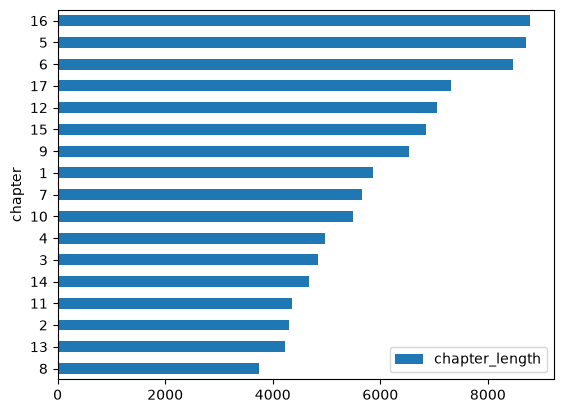

In [28]:
df[["chapter","chapter_length"]].sort_values("chapter_length").plot.barh(x="chapter",y="chapter_length")

In [37]:
import plotly.express as px
import plotly.graph_objects as go
import numpy as np

def plot_chapter_lengths(df, book_title):
    """1. Horizontal Bar Chart for Chapter Length with Mean Line"""
    mean_length = df['chapter_length'].mean()
    min_row = df.loc[df['chapter_length'].idxmin()]
    max_row = df.loc[df['chapter_length'].idxmax()]
    
    fig = px.bar(
        df,
        x='chapter_length',
        y='chapter_label',
        orientation='h',
        title=f'<b>{book_title}</b>: Chapter Lengths (Shortest: Ch {int(min_row["chapter"])}, Longest: Ch {int(max_row["chapter"])})',
        labels={'chapter_length': 'Word / Token Count', 'chapter_label': 'Chapter'},
        text='chapter_length',
        color='chapter_length',
        color_continuous_scale='Blues',
    )
    
    fig.add_vline(
        x=mean_length,
        line_dash='dash',
        line_color='red',
        annotation_text=f'Mean Length: {mean_length:.1f} words',
        annotation_position='top right',
        annotation_font=dict(color='red', size=12)
    )
    
    fig.update_layout(
        yaxis=dict(autorange='reversed'),
        template='plotly_white',
        showlegend=False,
        height=max(400, 100 + len(df) * 22)
    )
    return fig

def plot_character_stacked_area(df, book_title):
    """2. Stacked Area Chart (100% Relative Share)"""
    char_cols = [c for c in df.columns if c not in ['chapter', 'chapter_label', 'chapter_length']]
    df_long = df.melt(
        id_vars=['chapter'],
        value_vars=char_cols,
        var_name='character',
        value_name='mentions',
    )
    
    fig = px.area(
        df_long,
        x='chapter',
        y='mentions',
        color='character',
        groupnorm='percent',
        title=f'<b>{book_title}</b>: Relative Share of Character Mentions (Stacked Area 100%)',
        labels={'mentions': 'Share of Mentions (%)', 'chapter': 'Chapter'},
    )
    fig.update_layout(
        yaxis=dict(ticksuffix='%', range=[0, 100]),
        xaxis=dict(tickmode='linear', tick0=1, dtick=1),
        hovermode='x unified',
        legend_title_text='Character',
        template='plotly_white',
        height=480
    )
    fig.update_traces(hovertemplate='%{y:.1f}%')
    return fig

def plot_character_stacked_bar(df, book_title):
      """3. 100% Stacked Bar Chart"""
      char_cols = [
          c
          for c in df.columns
          if c not in ['chapter', 'chapter_label', 'chapter_length']
      ]
      df_long = df.melt(
          id_vars=['chapter', 'chapter_label'],
          value_vars=char_cols,
          var_name='character',
          value_name='mentions',
      )

      fig = px.bar(
          df_long,
          x='chapter_label',
          y='mentions',
          color='character',
          title=(
              f'<b>{book_title}</b>: Relative Character Mentions per Chapter (100%'
              ' Stacked Bar)'
          ),
          labels={'mentions': 'Share of Mentions (%)', 'chapter_label': 'Chapter'},
      )

      fig.update_layout(
          barmode='stack',
          barnorm='percent',  # Normalizes the stacked bars to 100%
          yaxis=dict(ticksuffix='%', range=[0, 100]),
          hovermode='x unified',
          legend_title_text='Character',
          template='plotly_white',
          height=480,
      )
      fig.update_traces(hovertemplate='%{y:.1f}%')
      return fig

Processing: Harry Potter and the Sorcerer’s Stone
Total Chapters: 17
Shortest Chapter: Chapter 8 (3738 words)
Longest Chapter:  Chapter 16 (8783 words)
Average Chapter Length: 5990.6 words


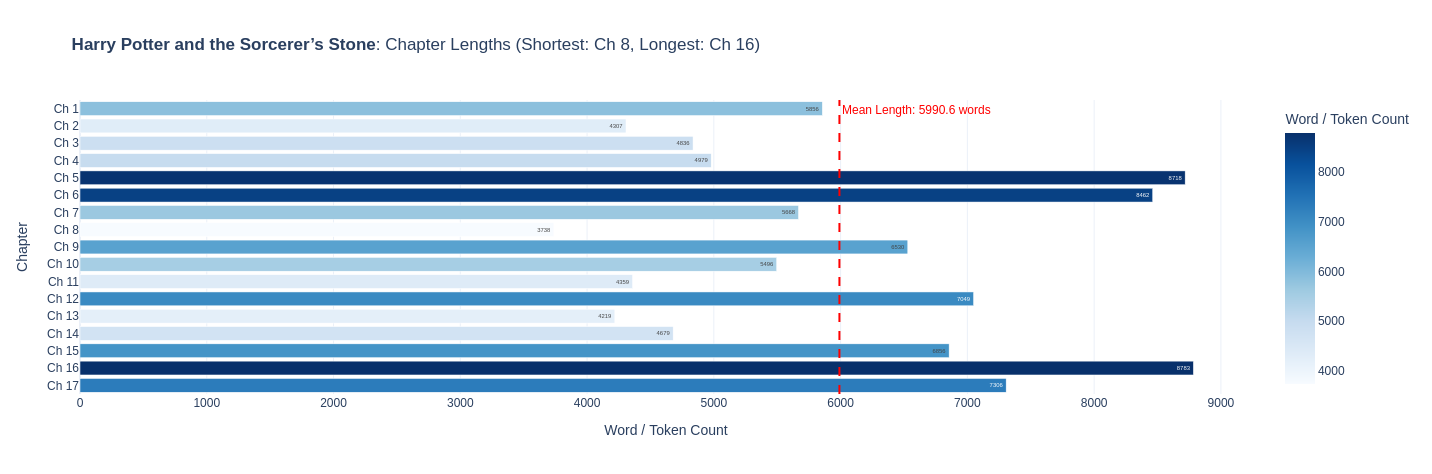

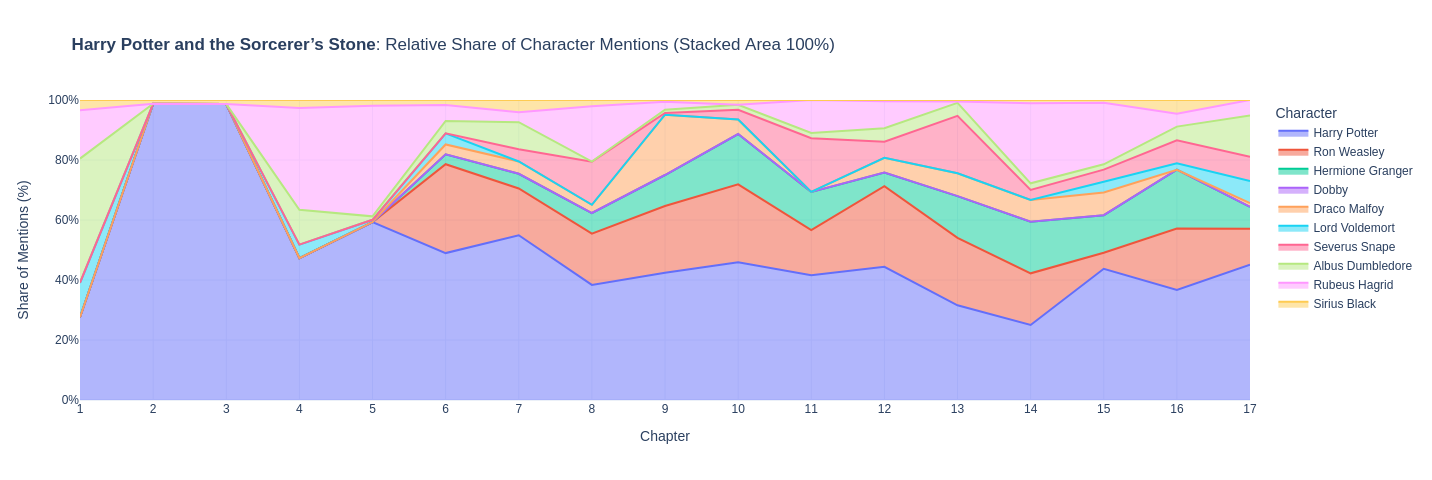

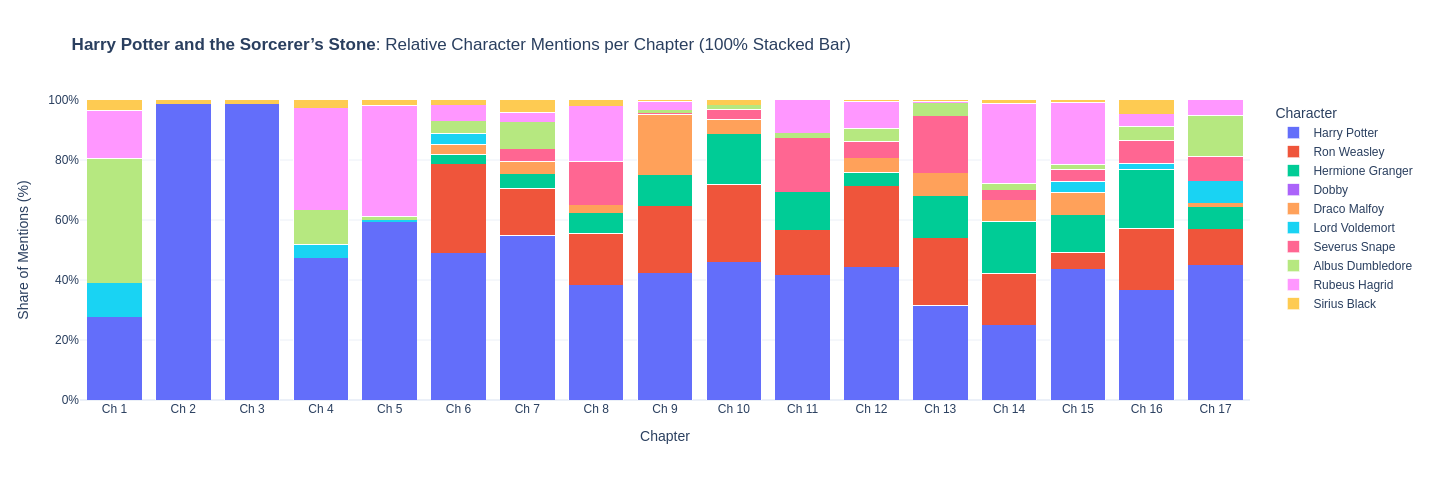

Processing: Harry Potter and the Chamber of Secrets
Total Chapters: 18
Shortest Chapter: Chapter 1 (3327 words)
Longest Chapter:  Chapter 11 (7751 words)
Average Chapter Length: 6221.9 words


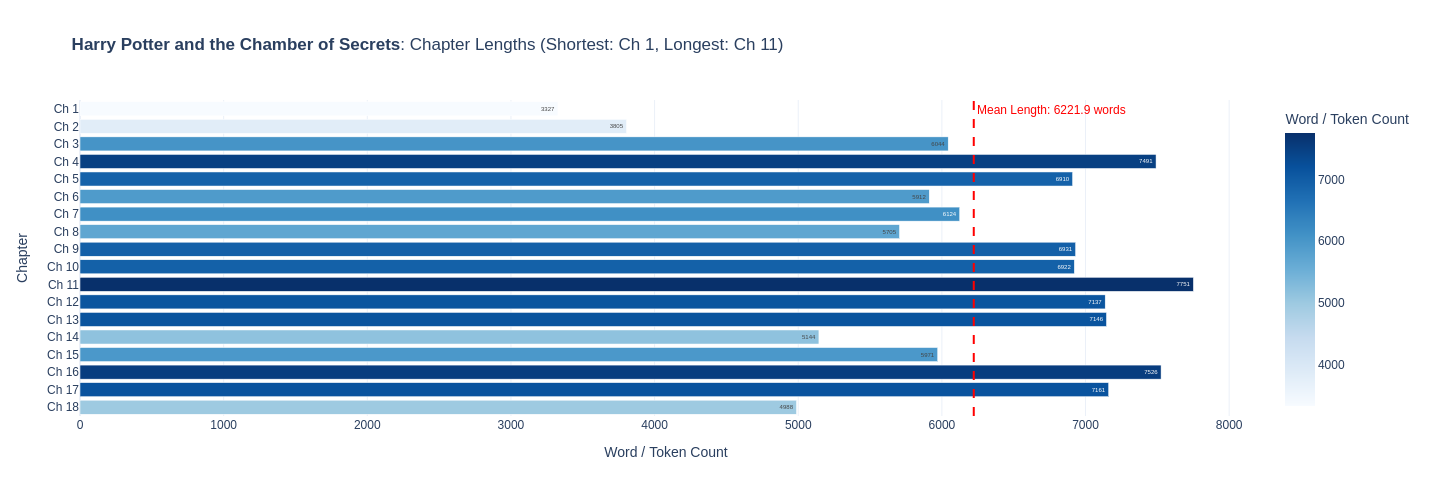

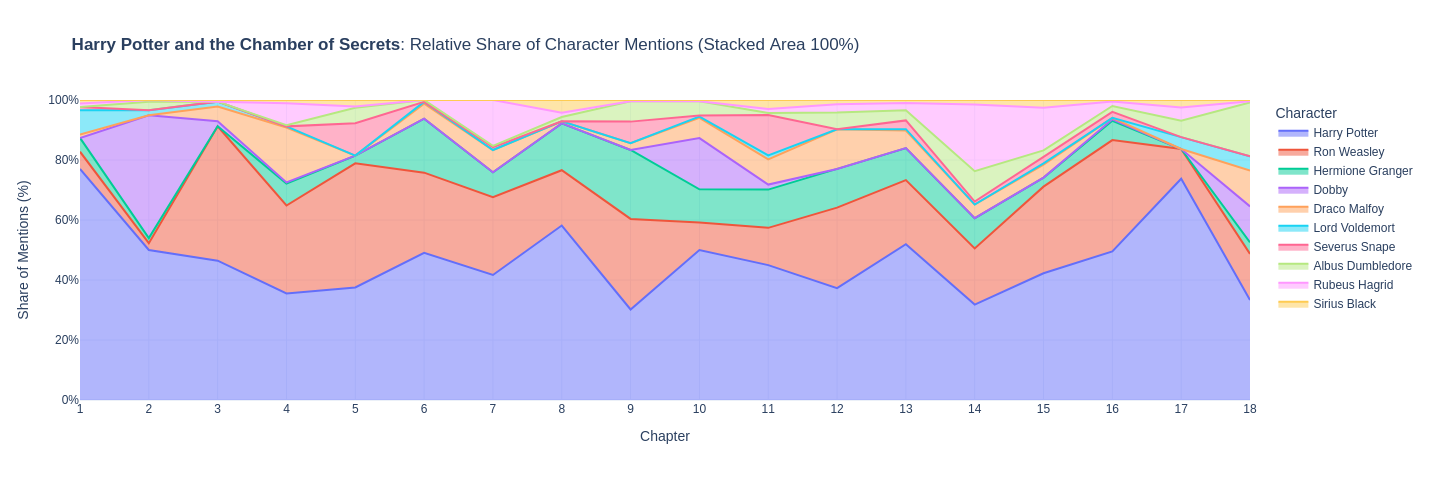

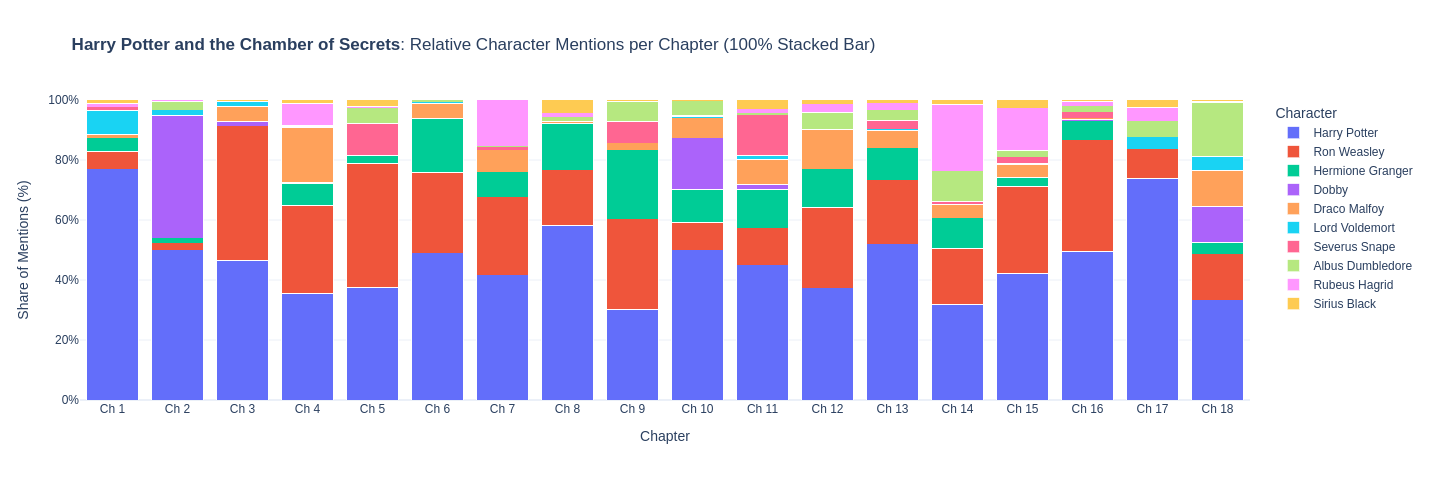

Processing: Harry Potter and the Prisoner of Azkaban
Total Chapters: 22
Shortest Chapter: Chapter 20 (2544 words)
Longest Chapter:  Chapter 21 (10002 words)
Average Chapter Length: 6489.5 words


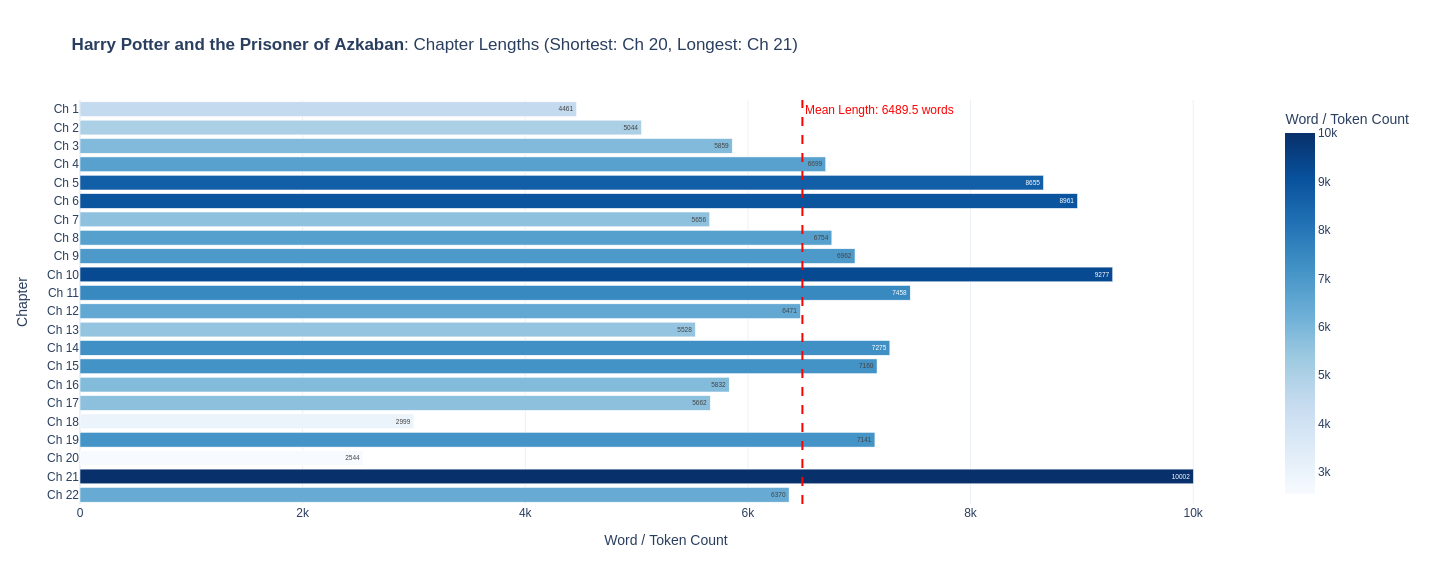

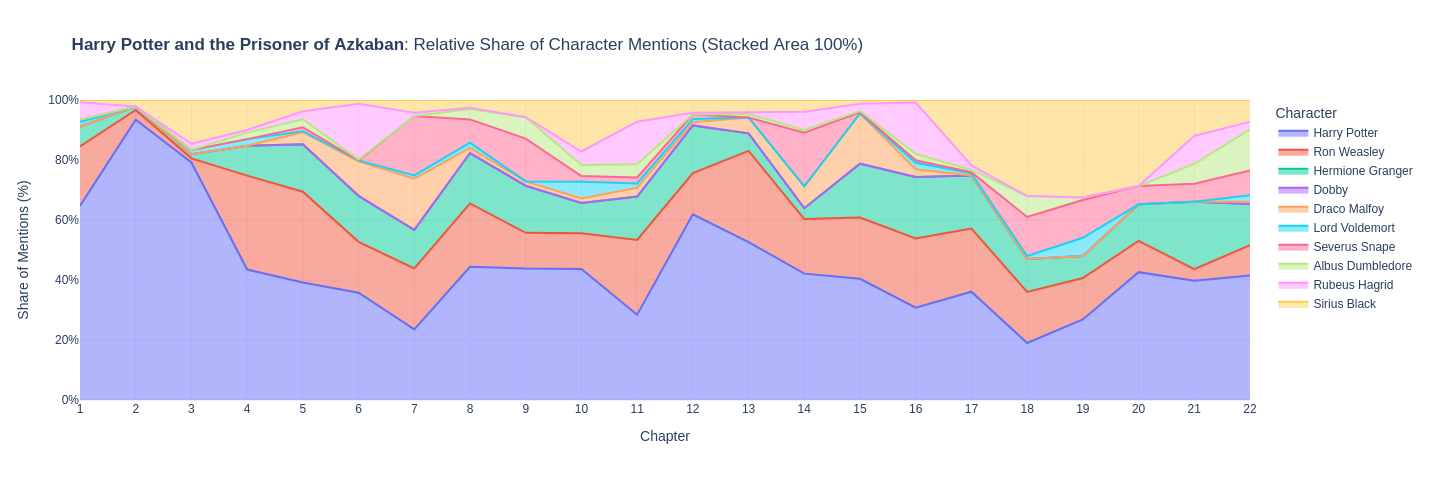

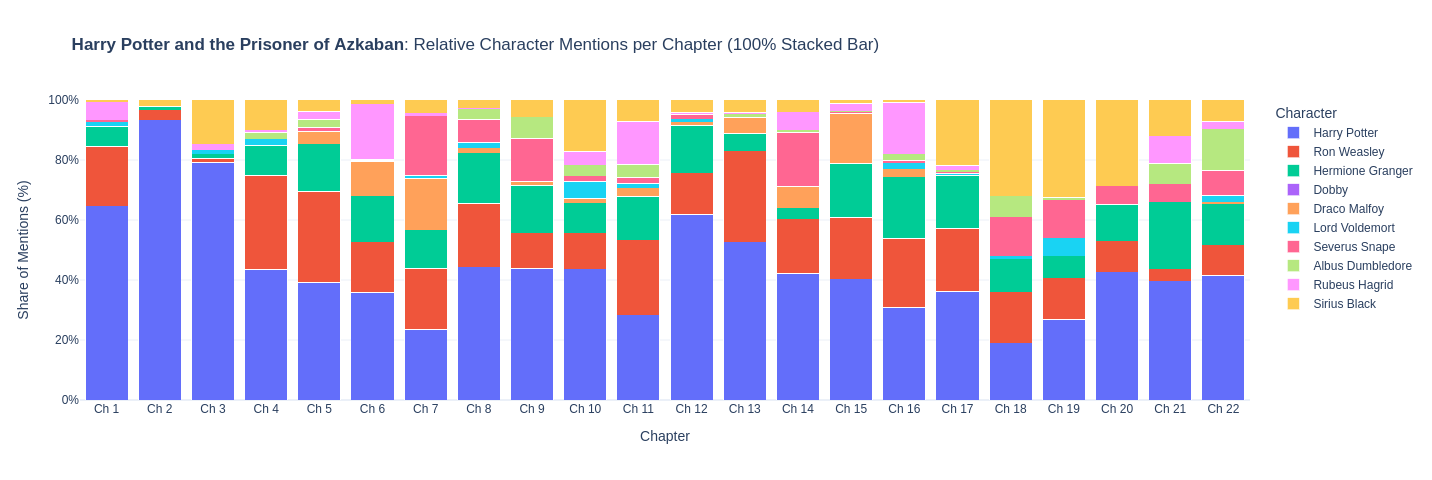

In [38]:
# Store dataframes for each book
book_dfs = {}

for book_title in first_3_books:
    print(f"="*60)
    print(f"Processing: {book_title}")
    print(f"="*60)
    
    # 1. Get chapters and build dataframe
    chapters = get_chapters(books[book_title])
    df_book = compose_character_df(chapters)
    df_book['chapter_label'] = [f'Ch {idx}' for idx in df_book['chapter']]
    book_dfs[book_title] = df_book
    
    # Identify shortest and longest chapters
    min_row = df_book.loc[df_book['chapter_length'].idxmin()]
    max_row = df_book.loc[df_book['chapter_length'].idxmax()]
    mean_len = df_book['chapter_length'].mean()
    
    print(f"Total Chapters: {len(df_book)}")
    print(f"Shortest Chapter: Chapter {int(min_row['chapter'])} ({int(min_row['chapter_length'])} words)")
    print(f"Longest Chapter:  Chapter {int(max_row['chapter'])} ({int(max_row['chapter_length'])} words)")
    print(f"Average Chapter Length: {mean_len:.1f} words")
    
    # Figure 1: Horizontal Bar Chart for Chapter Length (with Mean Line)
    fig_len = plot_chapter_lengths(df_book, book_title)
    fig_len.show()
    
    # Figure 2: Stacked Area Chart (100% Normalized)
    fig_area = plot_character_stacked_area(df_book, book_title)
    fig_area.show()
    
    # Figure 3: 100% Stacked Bar Chart
    fig_bar = plot_character_stacked_bar(df_book, book_title)
    fig_bar.show()


# Plotting Rationale

so I use stacked 100% area chart to represent the frequency of character to show the composition of each character to the character counts on each chapter, also it could show clearer trend of each character count over the book

and then the stacked 100% bar chart is to show the distribution of each character count in each chapter, it show more clearly for each character and in distinct chapters. but overall idea remain the same from stacked 100% area chart

# Harry Overpowering

since this is harry potter book, we will assume that normally harry will occur much more frequent in each chapter.

which is usually true since almost every chapters remaining distribution of harry to around 30% of the character counts.

there are a few chapters like
1. Sorcerer's Stone Ch.14 which harry percentage dropped to around 25%
2. Chamber of Secret Ch.9 around 30%
3. Prisoner of Azkhaban Ch. 7,11 which around 20-25% and chapter 18 down just right below 20% mark,

which most of them still having harry as the biggest contributor to the count but there are some, for example
1. Prisoner of Azkhaban chapter 18 the biggest contributor is the Sirius Black
2. Sorcere's Stone chapter 14, rebeus hagrid contribute more than harry

I which I know the story so I can tell you why it is that way but unfortunately I am not. :(